# Evaluación: comparación de modelos


In [1]:
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
import scikit_posthocs as sp
import seaborn as sns
from matplotlib.colors import to_hex
from matplotlib.lines import Line2D
from scipy import stats

PAPER_STYLE = {
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.04,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "normal",
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "lines.linewidth": 1.6,
    "patch.linewidth": 0.45,
}

DATASET_LABELS = {
    "explicit_mars": "MARS-Explicit",
    "implicit_mars": "MARS-Implicit",
    "itm": "ITM-Rec",
    "doris": "DORIS",
    "moocubex": "MOOCubeX",
    "mooccubex": "MOOCubeX",
    "coco": "COCO",
}

METRIC_ORDER = ["hit", "recall", "ndcg", "map", "mrr", "precision"]
MODEL_ORDER = [
    "EDuRec",
    "SASRec",
    "BERT4Rec",
    "SGL",
    "MultiVAE",
    "LightGCN",
    "NeuMF",
    "ItemKNN",
]
PROPOSED_C = "#D55E00"

In [2]:
def find_project_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "results").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("No encuentro la raiz del repositorio EDuRec.")


def safe_name(text):
    return re.sub(r"[^a-zA-Z0-9]+", "_", str(text).lower()).strip("_")


def dataset_label(name):
    return DATASET_LABELS.get(str(name).lower(), str(name).replace("_", " ").title())


def metric_sort_key(metric):
    base = str(metric).split("@", 1)[0].lower()
    return (
        METRIC_ORDER.index(base) if base in METRIC_ORDER else len(METRIC_ORDER),
        str(metric),
    )


def model_sort_key(model):
    return (
        MODEL_ORDER.index(model) if model in MODEL_ORDER else len(MODEL_ORDER),
        str(model),
    )


def load_results(results_dir, k):
    """Lee evaluation_results.csv (una fila por semilla) en formato largo."""
    frames = []
    for path in sorted(Path(results_dir).glob("*/evaluation_results.csv")):
        df = pd.read_csv(path)
        if df.empty or "model" not in df.columns or "seed" not in df.columns:
            continue
        metrics = [
            c
            for c in df.columns
            if c.lower().endswith(f"@{k}")
            and c.split("@", 1)[0].lower() in METRIC_ORDER
        ]
        if not metrics:
            continue
        df = df[["model", "seed", *metrics]].copy()
        df["dataset"] = dataset_label(path.parent.name)
        frames.append(df)
    if not frames:
        raise FileNotFoundError(
            f"No hay evaluation_results.csv con semillas en {results_dir}"
        )

    seeds = pd.concat(frames, ignore_index=True).melt(
        id_vars=["dataset", "seed", "model"],
        var_name="metric",
        value_name="value",
    )
    seeds["metric"] = seeds["metric"].str.lower()
    seeds["value"] = pd.to_numeric(seeds["value"], errors="coerce")
    return seeds.dropna(subset=["value"]).reset_index(drop=True)


def summarize(seeds):
    """Media y desviación típica de cada métrica por dataset y modelo."""
    summary = (
        seeds.groupby(["dataset", "model", "metric"], observed=True)["value"]
        .agg(
            mean="mean",
            std=lambda s: s.std(ddof=1) if len(s) > 1 else 0.0,
            n_seeds="count",
        )
        .reset_index()
    )
    summary["model"] = pd.Categorical(
        summary["model"],
        categories=sorted(summary["model"].unique(), key=model_sort_key),
        ordered=True,
    )
    summary["metric"] = pd.Categorical(
        summary["metric"],
        categories=sorted(summary["metric"].unique(), key=metric_sort_key),
        ordered=True,
    )
    return summary.sort_values(["metric", "dataset", "model"]).reset_index(drop=True)


def pivot_metric(seeds, metric):
    return (
        seeds[seeds["metric"] == str(metric)]
        .pivot_table(
            index=["dataset", "seed"],
            columns="model",
            values="value",
            observed=True,
        )
        .dropna(axis=0)
        .dropna(axis=1)
    )


def pivot_all_metrics(seeds):
    return (
        seeds.pivot_table(
            index=["dataset", "seed", "metric"],
            columns="model",
            values="value",
            observed=True,
        )
        .dropna(axis=0)
        .dropna(axis=1)
    )

In [3]:
def avg_ranks(values):
    return values.rank(axis=1, ascending=False, method="average").mean(axis=0)


def nemenyi_pvalues(values):
    table = values.copy()
    table.index = pd.RangeIndex(len(table))
    table.columns.name = None
    return sp.posthoc_nemenyi_friedman(table)


def critical_distance(n_models, n_blocks, alpha):
    q = stats.studentized_range.ppf(1 - alpha, n_models, np.inf) / math.sqrt(2)
    return float(q * math.sqrt(n_models * (n_models + 1) / (6 * n_blocks)))


def friedman_test(values, label):
    arrays = [values[column].to_numpy(dtype=float) for column in values.columns]
    statistic, pvalue = stats.friedmanchisquare(*arrays)
    ranks = avg_ranks(values)
    return {
        "comparison": label,
        "n_blocks": int(values.shape[0]),
        "n_models": int(values.shape[1]),
        "friedman_statistic": float(statistic),
        "friedman_pvalue": float(pvalue),
        "best_model": str(ranks.idxmin()),
        "best_rank": float(ranks.min()),
    }


def export_tables(seeds, summary, outdir, alpha):
    outdir.mkdir(parents=True, exist_ok=True)
    seeds.to_csv(outdir / "seed_values.csv", index=False)
    summary.to_csv(outdir / "mean_std_values.csv", index=False)

    rows = []
    for metric in summary["metric"].cat.categories:
        values = pivot_metric(seeds, metric)
        if values.shape[0] < 2 or values.shape[1] < 3:
            continue
        rows.append(friedman_test(values, str(metric)))
        nemenyi_pvalues(values).to_csv(outdir / f"nemenyi_{safe_name(metric)}.csv")

    combined = pivot_all_metrics(seeds)
    if combined.shape[0] >= 2 and combined.shape[1] >= 3:
        rows.append(friedman_test(combined, "all_metrics"))
        nemenyi_pvalues(combined).to_csv(outdir / "nemenyi_all_metrics.csv")

    pd.DataFrame(rows).to_csv(outdir / "friedman_results.csv", index=False)

In [4]:
def savefig(outdir, name, formats, dpi=300):
    outdir.mkdir(parents=True, exist_ok=True)
    for fmt in formats:
        plt.savefig(outdir / f"{name}.{fmt}", bbox_inches="tight", dpi=dpi)
    display(plt.gcf())


def apply_plot_style():
    sns.set_theme(
        context="paper",
        style="whitegrid",
        palette="colorblind",
        font="DejaVu Sans",
        rc=PAPER_STYLE,
    )


def style_axis(ax, grid_axis="y"):
    ax.set_axisbelow(True)
    ax.grid(axis=grid_axis, color="0.88", linewidth=0.7)
    ax.grid(axis="x" if grid_axis == "y" else "y", visible=False)
    sns.despine(ax=ax, trim=True)
    ax.tick_params(length=3, width=0.7, pad=5)


def overlay_std_errorbars(ax, data, x, hue, order, palette, value_col, std_col):
    """Dibuja barras de error (desviación típica) sobre líneas ya trazadas."""
    lookup = {
        (getattr(row, x), getattr(row, hue)): (
            getattr(row, value_col),
            getattr(row, std_col),
        )
        for row in data.itertuples()
    }
    categories = [tick.get_text() for tick in ax.get_xticklabels()]
    lines = [line for line in ax.lines if len(np.atleast_1d(line.get_xdata()))]
    for line, level in zip(lines, order):
        for xpos in line.get_xdata():
            idx = int(round(float(xpos)))
            if not 0 <= idx < len(categories):
                continue
            value, error = lookup.get((categories[idx], level), (np.nan, np.nan))
            if pd.isna(value) or pd.isna(error):
                continue
            ax.errorbar(
                xpos,
                value,
                yerr=error,
                color=palette.get(level, "0.2"),
                capsize=1.8,
                elinewidth=0.65,
                capthick=0.65,
                fmt="none",
                zorder=4,
            )


def model_palette(models, proposed_model, bar=False):
    if bar:
        colors = [
            "#E4572E",
            "#1F77B4",
            "#2CA02C",
            "#9467BD",
            "#FF7F0E",
            "#17BECF",
            "#D62728",
            "#8C564B",
            "#BCBD22",
            "#E377C2",
            "#4C78A8",
            "#72B7B2",
        ]
        proposed_color, base = colors[0], colors[1:]
    else:
        proposed_color = PROPOSED_C
        base = [
            to_hex(color).upper()
            for color in sns.color_palette("colorblind", max(len(models) + 2, 10))
            if to_hex(color).upper() != proposed_color
        ]
    palette, index = {}, 0
    for model in models:
        if model == proposed_model:
            palette[model] = proposed_color
        else:
            palette[model] = base[index % len(base)]
            index += 1
    return palette


def display_label(model, proposed_model):
    return "Propuesta" if str(model) == proposed_model else str(model)


def plot_grouped_bars(summary, outdir, formats, proposed_model, show_error_bars=False):
    for metric in summary["metric"].cat.categories:
        subset = summary[summary["metric"] == metric]
        if subset.empty:
            continue
        models = sorted(subset["model"].astype(str).unique(), key=model_sort_key)
        palette = model_palette(models, proposed_model, bar=True)
        apply_plot_style()
        fig, ax = plt.subplots(figsize=(7.4, 4.8), layout="constrained")
        sns.barplot(
            data=subset,
            x="dataset",
            y="mean",
            hue="model",
            hue_order=models,
            errorbar=None,
            palette=palette,
            edgecolor="0.25",
            linewidth=0.45,
            ax=ax,
        )
        if show_error_bars:
            datasets = [tick.get_text() for tick in ax.get_xticklabels()]
            lookup = {
                (row.dataset, row.model): (row.mean, row.std)
                for row in subset.itertuples()
            }
            for container, model in zip(ax.containers, models):
                for patch in container:
                    index = int(round(patch.get_x() + patch.get_width() / 2))
                    if not 0 <= index < len(datasets):
                        continue
                    value, error = lookup.get(
                        (datasets[index], model), (np.nan, np.nan)
                    )
                    if pd.isna(value) or pd.isna(error):
                        continue
                    ax.errorbar(
                        patch.get_x() + patch.get_width() / 2,
                        value,
                        yerr=error,
                        color="0.18",
                        capsize=1.8,
                        elinewidth=0.65,
                        capthick=0.65,
                        fmt="none",
                        zorder=4,
                    )
        ax.set_title(
            f"Comparación por conjunto de datos ({str(metric).upper()})", pad=10
        )
        ax.set_ylabel(str(metric).upper())
        style_axis(ax, "y")
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles,
            [display_label(label, proposed_model) for label in labels],
            title=None,
            frameon=False,
            ncol=3,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.16),
            borderaxespad=0.0,
        )
        savefig(outdir, f"bar_comparison_{safe_name(metric)}", formats)
        plt.close(fig)


def plot_metric_grid(summary, outdir, formats, proposed_model, k):
    apply_plot_style()
    metrics = list(summary["metric"].cat.categories)
    ncols = 3
    nrows = math.ceil(len(metrics) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(10.2, 3.5 * nrows))
    axes = np.atleast_1d(axes).reshape(-1)
    models = sorted(summary["model"].astype(str).unique(), key=model_sort_key)
    palette = model_palette(models, proposed_model)
    for ax, metric in zip(axes, metrics):
        subset = summary[summary["metric"] == metric]
        sns.lineplot(
            data=subset,
            x="dataset",
            y="mean",
            hue="model",
            style="model",
            hue_order=models,
            markers=True,
            dashes=False,
            errorbar=None,
            palette=palette,
            ax=ax,
            legend=False,
        )
        overlay_std_errorbars(
            ax, subset, "dataset", "model", models, palette, "mean", "std"
        )
        ax.set_title(str(metric).upper())
        ax.tick_params(axis="x", labelrotation=20)
        style_axis(ax, "y")
    for ax in axes[len(metrics) :]:
        ax.axis("off")
    fig.subplots_adjust(
        left=0.06, right=0.99, top=0.94, bottom=0.20, hspace=0.50, wspace=0.18
    )
    handles = [
        Line2D(
            [0],
            [0],
            color=palette[model],
            marker="o",
            linewidth=1.8,
            label=display_label(model, proposed_model),
        )
        for model in models
    ]
    if handles:
        fig.legend(
            handles,
            [handle.get_label() for handle in handles],
            loc="lower center",
            ncol=min(5, len(models)),
            frameon=False,
            bbox_to_anchor=(0.5, 0.03),
        )
    savefig(outdir, f"metric_profile_k{k}", formats)
    plt.close(fig)


def relative_improvement_table(summary, proposed_model, baseline):
    rows = []
    for metric in summary["metric"].cat.categories:
        values = summary[summary["metric"] == metric].pivot(
            index="dataset", columns="model", values="mean"
        )
        if proposed_model not in values.columns:
            continue
        for dataset, row in values.iterrows():
            candidates = row.drop(labels=[proposed_model], errors="ignore")
            if candidates.empty:
                continue
            if baseline == "best-baseline":
                baseline_model = str(candidates.idxmax())
                baseline_value = float(candidates.max())
            else:
                if baseline not in row.index:
                    continue
                baseline_model = baseline
                baseline_value = float(row[baseline])
            proposed_value = float(row[proposed_model])
            improvement = (
                100.0 * (proposed_value - baseline_value) / abs(baseline_value)
                if baseline_value
                else np.nan
            )
            rows.append(
                {
                    "dataset": dataset,
                    "metric": str(metric),
                    "proposed_model": proposed_model,
                    "baseline": baseline_model,
                    "proposed_value": proposed_value,
                    "baseline_value": baseline_value,
                    "relative_improvement_percent": improvement,
                }
            )
    return pd.DataFrame(rows)


def plot_relative_improvement(
    summary, outdir, formats, tables_dir, proposed_model, baseline, k
):
    improvement = relative_improvement_table(summary, proposed_model, baseline)
    tables_dir.mkdir(parents=True, exist_ok=True)
    improvement.to_csv(
        tables_dir / f"relative_improvement_{safe_name(proposed_model)}_k{k}.csv",
        index=False,
    )
    if improvement.empty:
        return
    pivot = improvement.pivot(
        index="dataset",
        columns="metric",
        values="relative_improvement_percent",
    ).reindex(columns=list(summary["metric"].cat.categories))
    apply_plot_style()
    fig, ax = plt.subplots(figsize=(7.2, 3.0), layout="constrained")
    vmax = max(float(np.nanmax(np.abs(pivot.to_numpy(dtype=float)))), 1.0)
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".1f",
        cmap="vlag",
        center=0,
        vmin=-vmax,
        vmax=vmax,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Mejora relativa (%)"},
        ax=ax,
    )
    ax.set_title(f"Mejora relativa de Propuesta frente a {baseline}")
    savefig(
        outdir,
        f"relative_improvement_heatmap_{safe_name(proposed_model)}_k{k}",
        formats,
    )
    plt.close(fig)


def plot_rank_heatmap(seeds, summary, outdir, formats, tables_dir, proposed_model, k):
    rows = []
    for metric in summary["metric"].cat.categories:
        ranked = pivot_metric(seeds, metric).rank(
            axis=1, ascending=False, method="average"
        )
        for (dataset, seed), row in ranked.iterrows():
            for model, rank in row.items():
                rows.append(
                    {
                        "dataset": dataset,
                        "seed": seed,
                        "metric": str(metric),
                        "model": str(model),
                        "rank": rank,
                    }
                )
    rank_df = pd.DataFrame(rows)
    tables_dir.mkdir(parents=True, exist_ok=True)
    rank_df.to_csv(tables_dir / f"ranks_k{k}.csv", index=False)

    mean_ranks = rank_df.groupby(["dataset", "metric", "model"], as_index=False)[
        "rank"
    ].mean()
    pivot = mean_ranks.pivot(
        index="model", columns=["dataset", "metric"], values="rank"
    )
    pivot = pivot.reindex(index=sorted(pivot.index, key=model_sort_key))
    pivot.index = [display_label(model, proposed_model) for model in pivot.index]
    apply_plot_style()
    fig, ax = plt.subplots(
        figsize=(max(9.0, 0.42 * pivot.shape[1] + 3.0), 4.8),
        layout="constrained",
    )
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".1f",
        cmap="viridis_r",
        linewidths=0.35,
        linecolor="white",
        cbar_kws={"label": "Ranking medio (1 = mejor)"},
        ax=ax,
    )
    ax.set_title(f"Rankings por conjunto de datos y métrica (@{k})")
    ax.tick_params(axis="x", labelrotation=45)
    savefig(outdir, f"rank_heatmap_k{k}", formats)
    plt.close(fig)


def plot_cd_diagram(values, title, outdir, name, formats, alpha, proposed_model):
    ranks = avg_ranks(values).sort_values()
    pvalues = nemenyi_pvalues(values).reindex(index=ranks.index, columns=ranks.index)
    cd = critical_distance(values.shape[1], values.shape[0], alpha)
    labels = [display_label(model, proposed_model) for model in ranks.index]
    ranks.index = labels
    pvalues.index = labels
    pvalues.columns = labels
    apply_plot_style()
    fig, ax = plt.subplots(
        figsize=(
            max(8.8, 0.38 * len(ranks) + 7.2),
            max(4.0, 0.44 * len(ranks) + 1.7),
        )
    )
    fig.suptitle(title, y=0.98, fontsize=10.5, fontweight="normal")
    fig.subplots_adjust(left=0.18, right=0.82, top=0.88, bottom=0.10)
    highlighted = display_label(proposed_model, proposed_model)
    colors = {
        str(model): PROPOSED_C if str(model) == highlighted else "#128CBD"
        for model in ranks.index
    }
    sp.critical_difference_diagram(
        ranks,
        pvalues,
        cd=cd,
        alpha=alpha,
        ax=ax,
        color_palette=colors,
        label_fmt_left="{label}\n({rank:.2f})",
        label_fmt_right="{label}\n({rank:.2f})",
        label_props={
            "fontsize": 9.0,
            "linespacing": 1.25,
            "bbox": {
                "facecolor": "white",
                "edgecolor": "none",
                "pad": 1.5,
                "alpha": 0.96,
            },
        },
        marker_props={"s": 26, "zorder": 3},
        elbow_props={"linewidth": 1.15},
        crossbar_props={"linewidth": 1.6, "color": "0.12"},
        text_h_margin=0.06,
    )
    ax.tick_params(axis="x", which="major", pad=12, labelsize=9)
    for text in ax.get_xticklabels():
        text.set_bbox(
            {"facecolor": "white", "edgecolor": "none", "pad": 0.35, "alpha": 0.96}
        )
    for text in ax.texts:
        if text.get_text().startswith("CD = "):
            text.set(
                fontsize=9,
                y=1.12,
                bbox={
                    "facecolor": "white",
                    "edgecolor": "none",
                    "pad": 1.4,
                    "alpha": 0.98,
                },
            )
    if ax.get_ylim()[1] < 1.28:
        ax.set_ylim(ax.get_ylim()[0], 1.28)
    savefig(outdir, name, formats)
    plt.close(fig)


def plot_cd_diagrams(seeds, summary, outdir, formats, alpha, proposed_model, k):
    for metric in summary["metric"].cat.categories:
        values = pivot_metric(seeds, metric)
        if values.shape[0] >= 2 and values.shape[1] >= 3:
            plot_cd_diagram(
                values,
                f"Diagrama de diferencia crítica ({str(metric).upper()}, alfa={alpha})",
                outdir,
                f"cd_diagram_{safe_name(metric)}",
                formats,
                alpha,
                proposed_model,
            )
    combined = pivot_all_metrics(seeds)
    if combined.shape[0] >= 2 and combined.shape[1] >= 3:
        plot_cd_diagram(
            combined,
            f"Diagrama de diferencia crítica (todas las métricas @{k}, alfa={alpha})",
            outdir,
            f"cd_diagram_all_metrics_k{k}",
            formats,
            alpha,
            proposed_model,
        )

## Configuración


In [5]:
PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "results" / "evaluations"
PLOTS_DIR = PROJECT_ROOT / "results" / "plots" / "evaluation"
TABLES_DIR = PROJECT_ROOT / "results" / "tables" / "evaluation"
K = 20
PROPOSED_MODEL = "EDuRec"
BASELINE_FOR_IMPROVEMENT = "best-baseline"
ALPHA = 0.05
FORMATS = ["png"]
SHOW_ERROR_BARS = True

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Resultados: {RESULTS_DIR}")
print(f"Figuras:    {PLOTS_DIR}")
print(f"Tablas:     {TABLES_DIR}")

Resultados: /home/pacatro/Code/projects/EDuRec/results/evaluations
Figuras:    /home/pacatro/Code/projects/EDuRec/results/plots/evaluation
Tablas:     /home/pacatro/Code/projects/EDuRec/results/tables/evaluation


## Cargar resultados y calcular media ± std


In [6]:
seeds = load_results(RESULTS_DIR, K)
if PROPOSED_MODEL not in set(seeds["model"]):
    raise ValueError(
        f"El modelo propuesto {PROPOSED_MODEL!r} no está en los resultados."
    )
summary = summarize(seeds)
print(
    f"{summary['dataset'].nunique()} datasets, "
    f"{summary['model'].nunique()} modelos, "
    f"{summary['metric'].nunique()} métricas."
)
summary.head()

5 datasets, 8 modelos, 6 métricas.


,dataset,model,metric,mean,std,n_seeds
0,DORIS,EDuRec,hit@20,0.933949,0.000158,3
1,DORIS,SASRec,hit@20,0.474150,0.000934,3
2,DORIS,BERT4Rec,hit@20,0.382837,0.005778,3
3,DORIS,SGL,hit@20,0.228603,0.001885,3
4,DORIS,MultiVAE,hit@20,0.186396,0.003248,3


## Exportar estadísticos


In [7]:
export_tables(seeds, summary, TABLES_DIR, ALPHA)

## Generar figuras


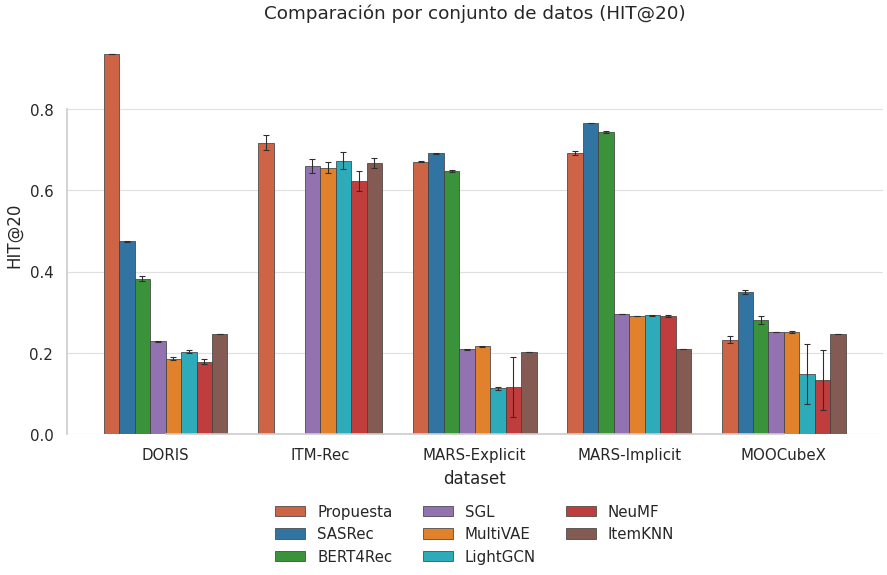

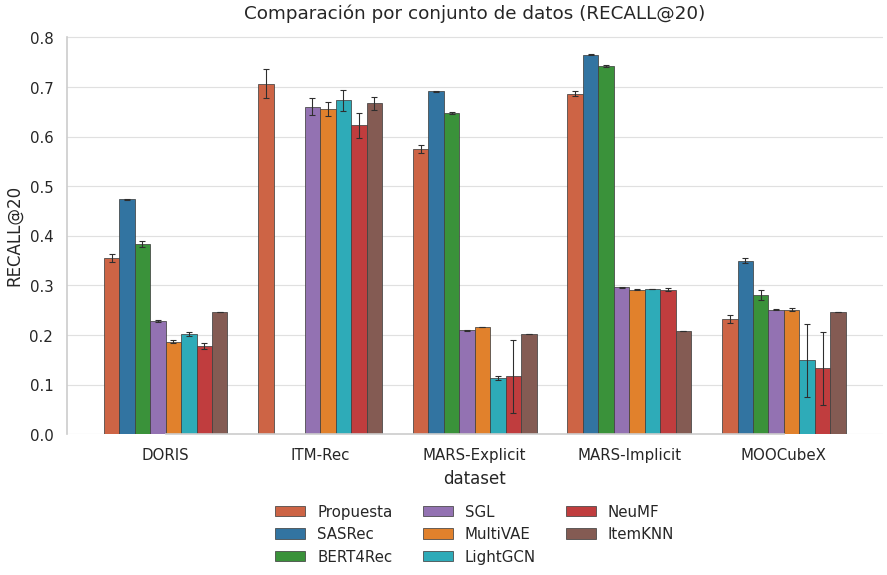

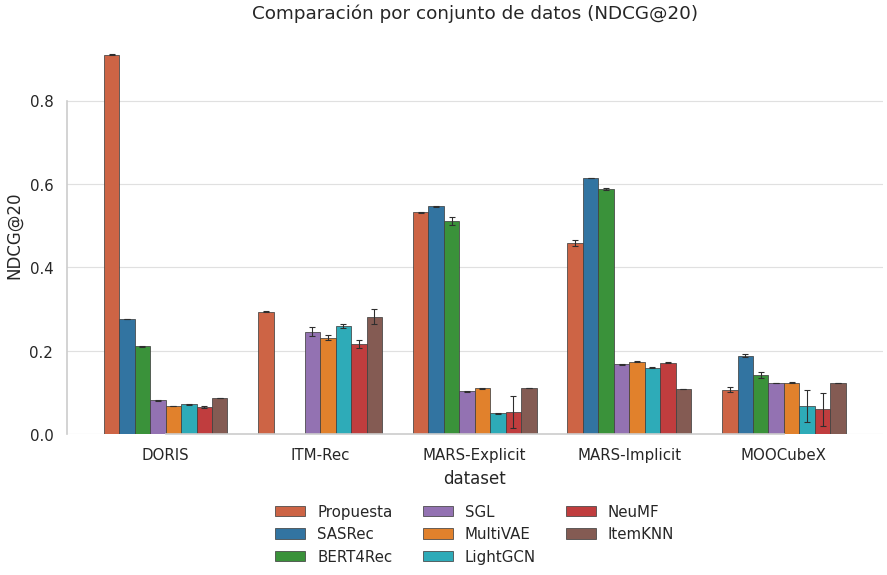

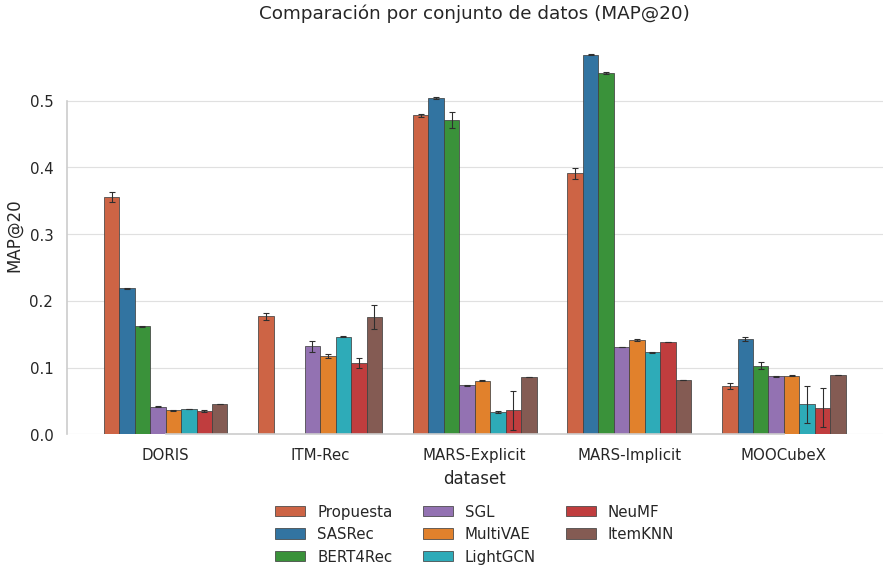

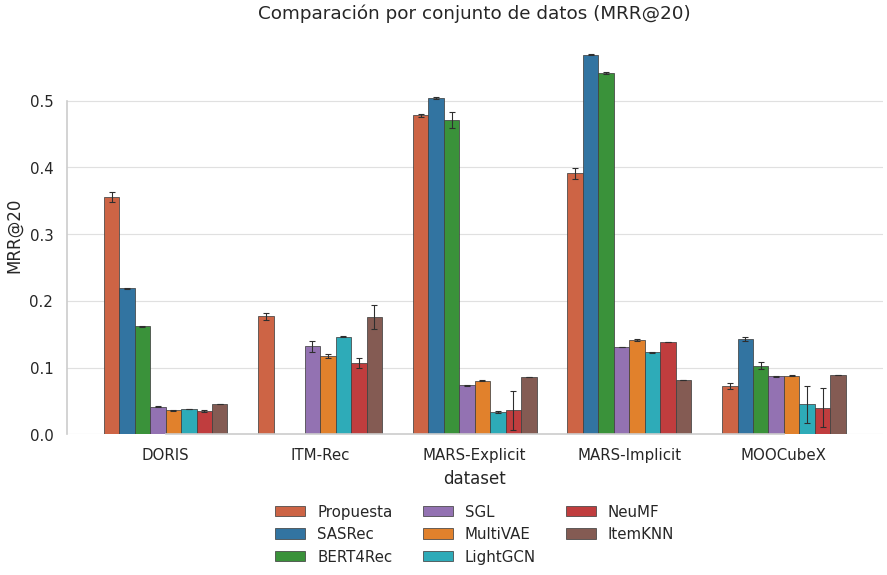

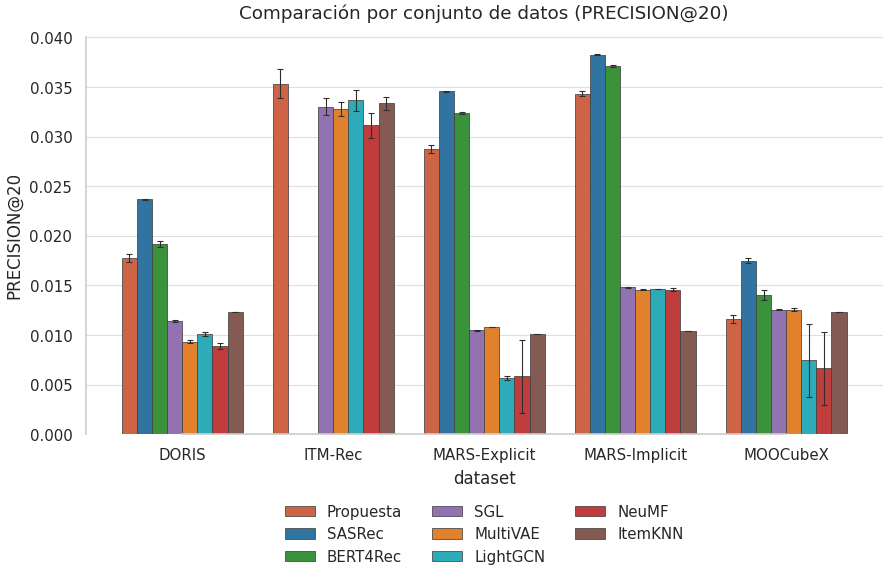

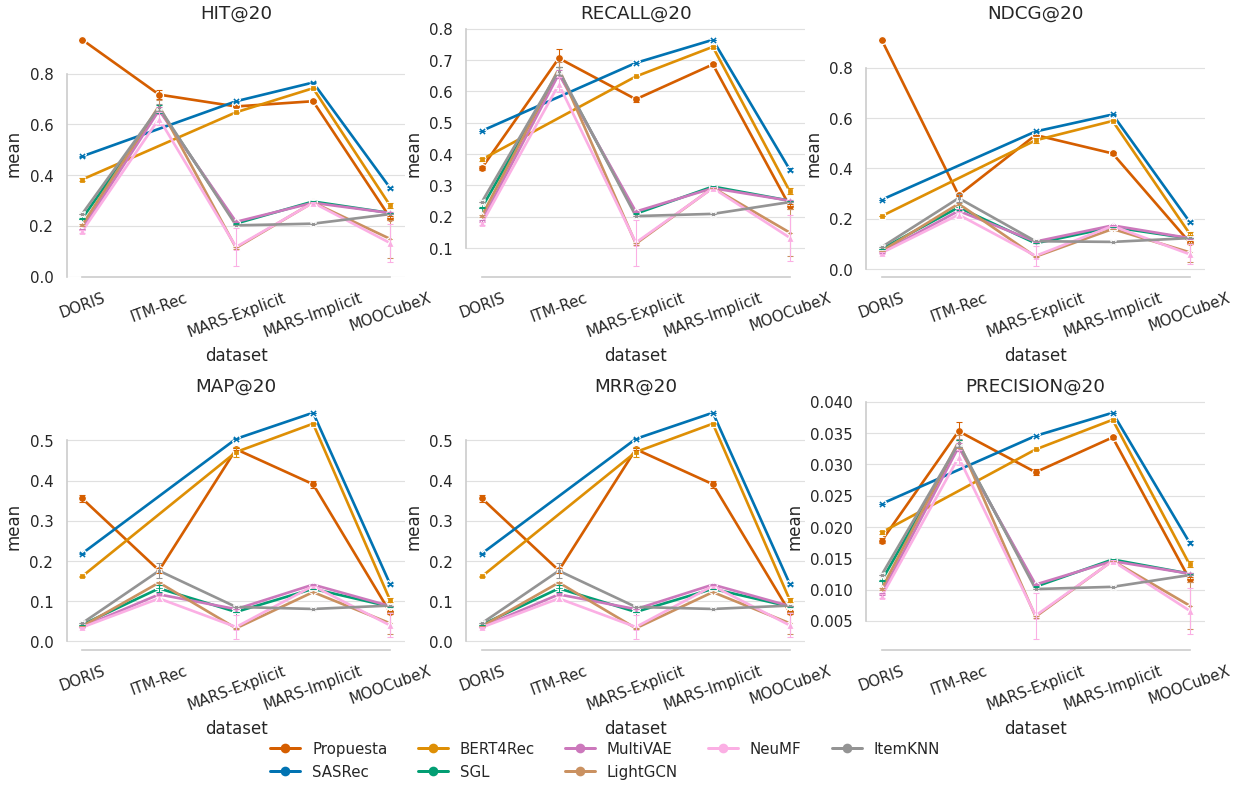

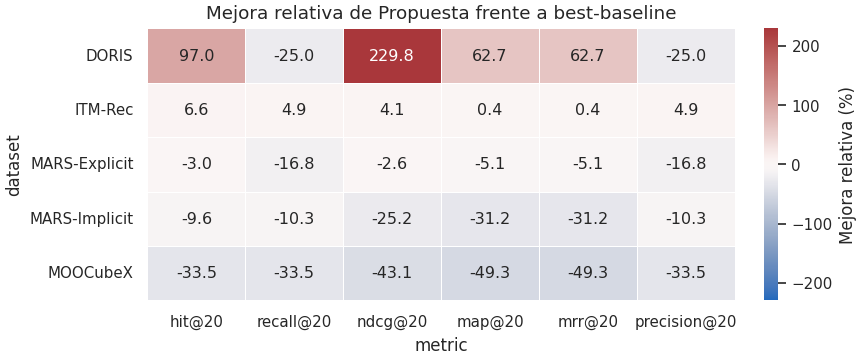

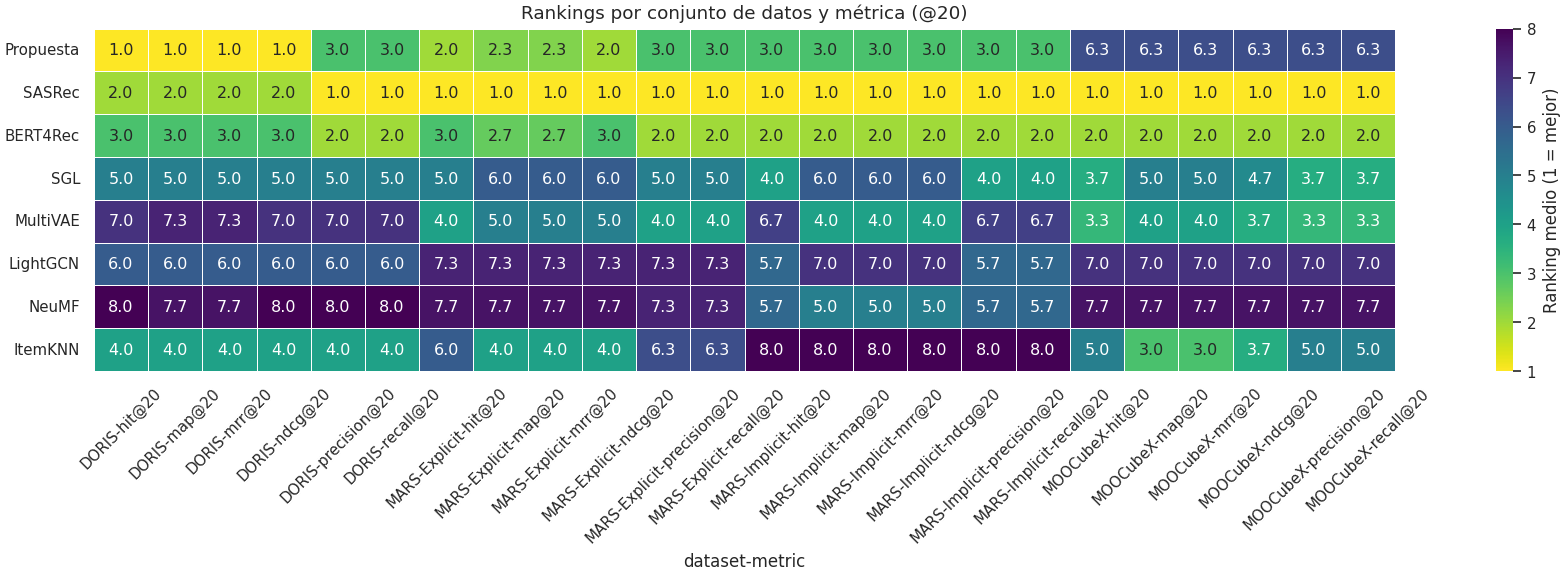

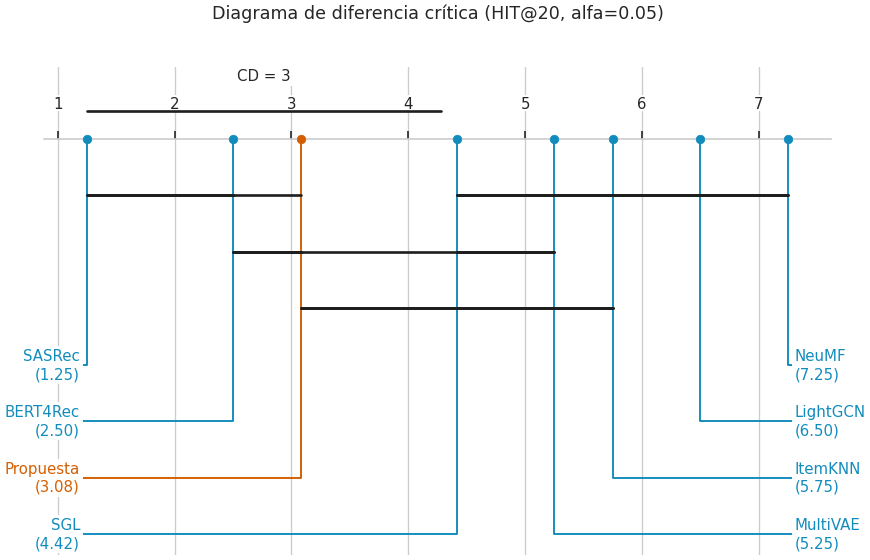

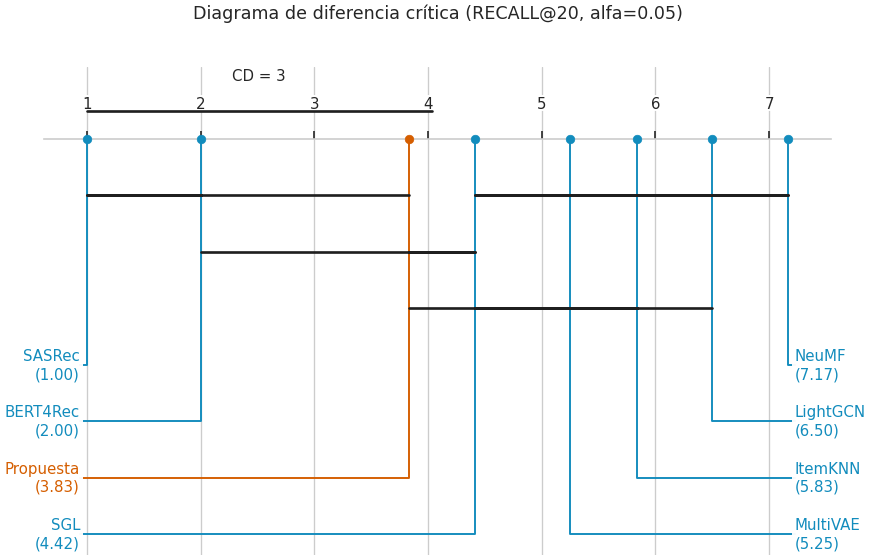

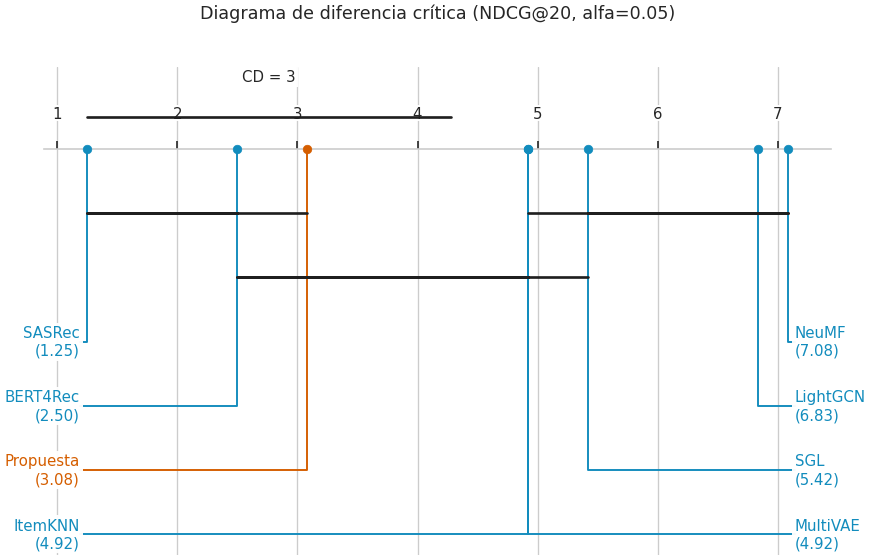

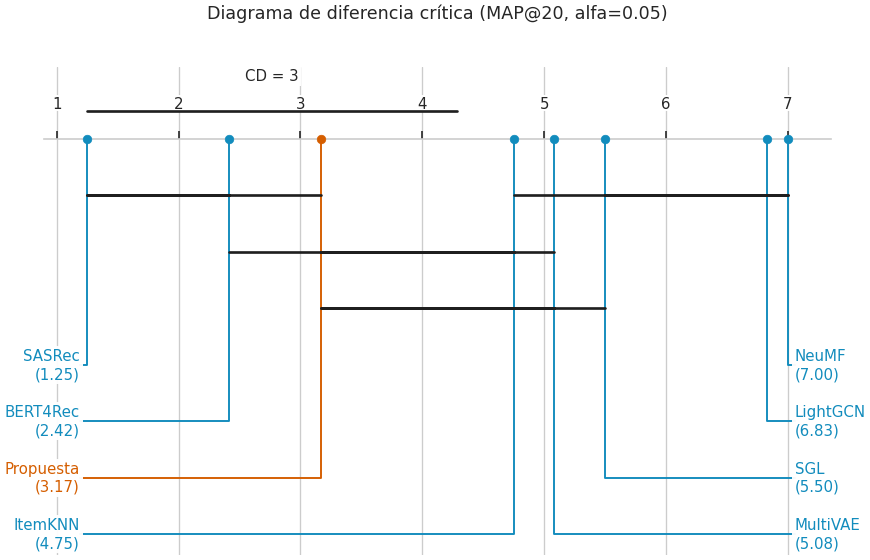

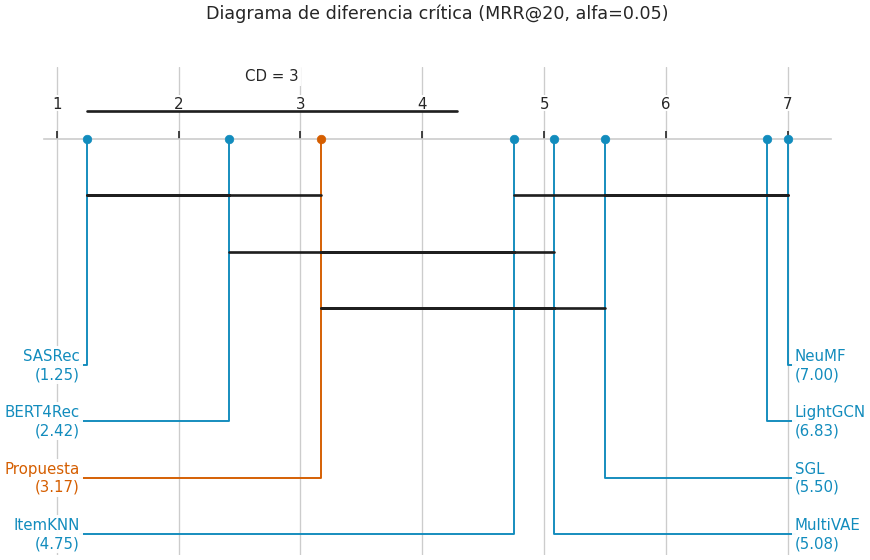

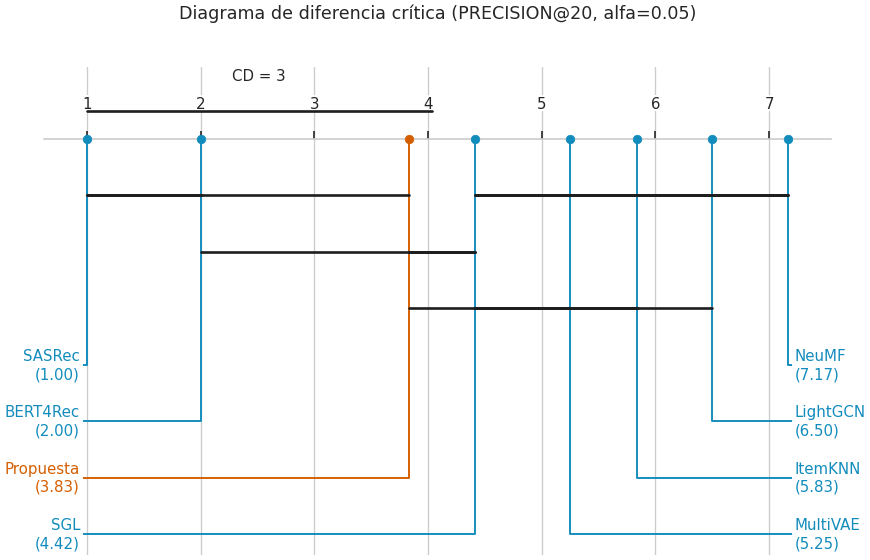

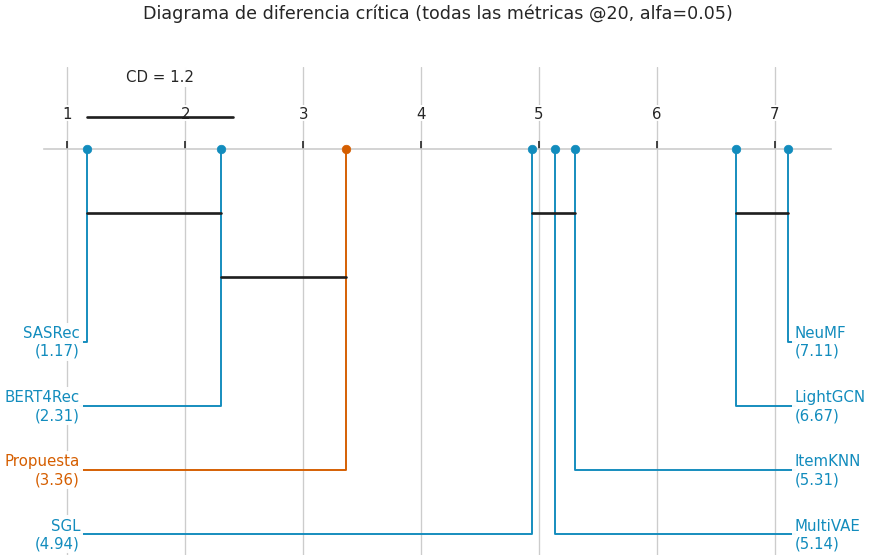

Generadas 16 figuras en /home/pacatro/Code/projects/EDuRec/results/plots/evaluation


['bar_comparison_hit_20.png',
 'bar_comparison_map_20.png',
 'bar_comparison_mrr_20.png',
 'bar_comparison_ndcg_20.png',
 'bar_comparison_precision_20.png',
 'bar_comparison_recall_20.png',
 'cd_diagram_all_metrics_k20.png',
 'cd_diagram_hit_20.png',
 'cd_diagram_map_20.png',
 'cd_diagram_mrr_20.png',
 'cd_diagram_ndcg_20.png',
 'cd_diagram_precision_20.png',
 'cd_diagram_recall_20.png',
 'metric_profile_k20.png',
 'rank_heatmap_k20.png',
 'relative_improvement_heatmap_edurec_k20.png']

In [8]:
plot_grouped_bars(
    summary, PLOTS_DIR, FORMATS, PROPOSED_MODEL, show_error_bars=SHOW_ERROR_BARS
)
plot_metric_grid(summary, PLOTS_DIR, FORMATS, PROPOSED_MODEL, K)
plot_relative_improvement(
    summary,
    PLOTS_DIR,
    FORMATS,
    TABLES_DIR,
    PROPOSED_MODEL,
    BASELINE_FOR_IMPROVEMENT,
    K,
)
plot_rank_heatmap(seeds, summary, PLOTS_DIR, FORMATS, TABLES_DIR, PROPOSED_MODEL, K)
plot_cd_diagrams(seeds, summary, PLOTS_DIR, FORMATS, ALPHA, PROPOSED_MODEL, K)

files = sorted(p.name for p in PLOTS_DIR.iterdir() if p.is_file())
print(f"Generadas {len(files)} figuras en {PLOTS_DIR}")
files